In [51]:
# Install RDKit and visualization module
!pip install rdkit
!pip install py3Dmol

In [52]:
# Importar librerías
import os
import collections
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from scipy.spatial import distance
from google.colab import drive

from rdkit import Chem, RDConfig, DataStructs
from rdkit.Chem import AllChem, rdMolAlign, ChemicalFeatures, Draw
from rdkit.ML.Cluster import Butina
import py3Dmol




In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


List of compounds to build the model with

In [54]:
# Define the COX-2 selective ligands
smiles_list = { "FEBUXOSTAT": "Cc1nc(-c2ccc(OCC(C)C)c(C#N)c2)sc1C(=O)O",
"BENDAZAC": "O=C(O)COc1nn(Cc2ccccc2)c2ccccc12", "TOPIROXOSTAT": "N#Cc1cc(-c2n[nH]c(-c3ccncc3)n2)ccn1"
}

In [55]:
#Convert SMILES to RDKit Mol objects
molecules = {}
for name, smi in smiles_list.items():
    mol = Chem.MolFromSmiles(smi)
    #Add hydrogens to each molecule
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, AllChem.ETKDG()) #GENERATE 3D conformer
    params = AllChem.ETKDG()
    params.randomSeed = 42
    AllChem.EmbedMolecule(mol, params)
    AllChem.UFFOptimizeMolecule(mol) # energy minimization
    molecules[name]= mol
    #, generate 3D coordinates, minimize and represent the structure

print(f"Prepared {len(molecules)} molecules with 3D coordinates")

Prepared 3 molecules with 3D coordinates


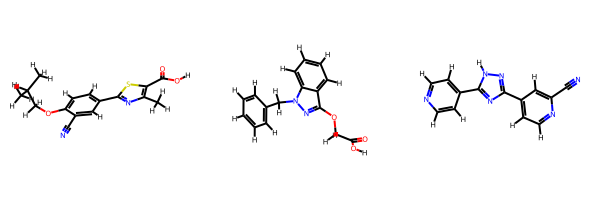

In [56]:
#visualization
Draw.MolsToGridImage(list(molecules.values()))

In [57]:
print(molecules)

{'FEBUXOSTAT': <rdkit.Chem.rdchem.Mol object at 0x7e9ad92ca1f0>, 'BENDAZAC': <rdkit.Chem.rdchem.Mol object at 0x7e9ad92c9850>, 'TOPIROXOSTAT': <rdkit.Chem.rdchem.Mol object at 0x7e9ad92c91c0>}


In [58]:
# Align molecules to the ref ligand ()
ref_mol = molecules["FEBUXOSTAT"]

# O3A
for name, mol in molecules.items():
    if name != "FEBUXOSTAT":
        o3a = rdMolAlign.GetO3A(mol, ref_mol)
        rmsd = o3a.Align()

In [59]:
# Convert all aligned molecules to MolBlocks for visualization
mol_blocks = []
for name, mol in molecules.items():
    mb = Chem.MolToMolBlock(mol)
    mol_blocks.append((name, mb))

# Create a 3D viewer
viewer = py3Dmol.view(width=500, height=500)

# Add each molecule with a different color style
colors = ["blue", "green", "orange"]
for i, (name, mb) in enumerate(mol_blocks):
    viewer.addModel(mb, "mol")
    viewer.setStyle({"model": i}, {"stick": {"color": colors[i]}})

viewer.zoomTo()
viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

4. Identify pharmacophoric features
As described above, the aim of this talktorial is to generate a ligand-based ensemble pharmacophore from a set of ligands. First, we need to extract pharmacophore features per ligand. Therefore, we load a feature factory. We use the default feature definitions.

Chemical features in the RDKit are defined using a SMARTS-based feature definition language (described in detail in the RDKit book). To identify chemical features in molecules, you first must build a feature factory and then use the factory to search for features. The individual features carry information about their family (e.g. donor, acceptor, etc.), type (a more detailed description), and the atom(s) that is/are associated with the feature.

In [60]:
# Load RDKit's default feature definition file
fdef_name = os.path.join(RDConfig.RDDataDir, 'BaseFeatures.fdef')
factory = ChemicalFeatures.BuildFeatureFactory(fdef_name)

# Detect features for each molecule
pharmacophore_data = {}
for name, mol in molecules.items():
    feats = factory.GetFeaturesForMol(mol)
    pharmacophore_data[name] = [(f.GetType(), f.GetFamily(), f.GetPos()) for f in feats]

# Print detected features
for name, features in pharmacophore_data.items():
    print(f"\n{name} Pharmacophore Features:")
    for ftype, ffamily,pos in features:
        print(f" - {ftype} ({ffamily}) ")


FEBUXOSTAT Pharmacophore Features:
 - SingleAtomDonor (Donor) 
 - SingleAtomAcceptor (Acceptor) 
 - SingleAtomAcceptor (Acceptor) 
 - SingleAtomAcceptor (Acceptor) 
 - SingleAtomAcceptor (Acceptor) 
 - AcidicGroup (NegIonizable) 
 - Arom5 (Aromatic) 
 - Arom6 (Aromatic) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydrophobe) 
 - RH6_6 (LumpedHydrophobe) 
 - iPropyl (LumpedHydrophobe) 

BENDAZAC Pharmacophore Features:
 - SingleAtomDonor (Donor) 
 - SingleAtomAcceptor (Acceptor) 
 - SingleAtomAcceptor (Acceptor) 
 - SingleAtomAcceptor (Acceptor) 
 - SingleAtomAcceptor (Acceptor) 
 - AcidicGroup (NegIonizable) 
 - Arom5 (Aromatic) 
 - Arom6 (Aromatic) 
 - Arom6 (Aromatic) 
 - ThreeWayAttach (Hydrophobe) 
 - ThreeWayAttach (Hydr

In [61]:
features = [f for f in factory.GetFeaturesForMol(molecules["FEBUXOSTAT"])]
feature_frequency = collections.Counter([f.GetFamily() for f in features])
print("\nFeature frequency in FEBUXOSTAT:")
print(feature_frequency)


Feature frequency in FEBUXOSTAT:
Counter({'Hydrophobe': 10, 'Acceptor': 4, 'Aromatic': 2, 'LumpedHydrophobe': 2, 'Donor': 1, 'NegIonizable': 1})


In [62]:
rows = []
for name, features in pharmacophore_data.items():
    for ftype, ffamily, pos in features:
        rows.append({
            "Ligand": name,
            "Feature_Type": ftype,
            "Feature_Family": ffamily,
            "X": round(pos.x, 3),
            "Y": round(pos.y, 3),
            "Z": round(pos.z, 3)
        })

#  DataFrame
df_features = pd.DataFrame(rows)

# rusume of the count of the number of each feature per compound
summary = df_features.groupby(["Ligand", "Feature_Family"]).size().unstack(fill_value=0)

print("Pharmacophore Feature Family Summary per Ligand:")
display(summary)

Pharmacophore Feature Family Summary per Ligand:


Feature_Family,Acceptor,Aromatic,Donor,Hydrophobe,LumpedHydrophobe,NegIonizable
Ligand,,,,,,
BENDAZAC,4,3,1,11,2,1
FEBUXOSTAT,4,2,1,10,2,1
TOPIROXOSTAT,4,3,3,6,0,0


 Build a pharmacophore model

The idea of building a k-means clustering pharmacophore model was taken from a youtube video https://youtu.be/ddmR5PrPugI?si=wpgAVNmWpzxDnP27. I modified the code for suiting on mu goals

In [63]:


# Configuration
min_cluster_size = 3  #all the molecules must share the feature
common_features = []

# Procesamos cada feature family separetly
for family in df_features['Feature_Family'].unique():
    # 1. Obtenemos TODAS las coordenadas de esa familia en TODAS las moléculas
    subset = df_features[df_features['Feature_Family'] == family]
    coords = subset[['X', 'Y', 'Z']].values

    # Si hay menos puntos totales que el mínimo requerido, saltamos
    if len(coords) < min_cluster_size:
        continue

    # Algoritmo K-Means para buscar los centros
    # Probamos dividir los puntos en k clusters (desde 1 hasta 10 posibles sitios)
    best_centers = []

    # Iteramos buscando la mejor agrupación
    for k in range(1, min(len(coords), 15)):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(coords)

        # Validamos cada cluster encontrado
        valid_centers_k = []
        for i in range(k):
            # Puntos que pertenecen a este cluster 'i'
            cluster_points_indices = np.where(labels == i)[0]
            cluster_subset = subset.iloc[cluster_points_indices]

            unique_ligands = cluster_subset['Ligand'].nunique()

            if unique_ligands >= min_cluster_size:
                center = kmeans.cluster_centers_[i]
                valid_centers_k.append({
                    "Feature_Family": family,
                    "X": round(center[0], 3),
                    "Y": round(center[1], 3),
                    "Z": round(center[2], 3),
                    "Shared_By": unique_ligands
                })

        # Nos quedamos con la configuración 'k' que encuentre MÁS features válidas
        if len(valid_centers_k) > len(best_centers):
            best_centers = valid_centers_k

    # Añadimos los mejores centros encontrados a la lista final
    common_features.extend(best_centers)

# Crear DataFrame final
df_common = pd.DataFrame(common_features)
if not df_common.empty:
    df_common = df_common.sort_values(by="Shared_By", ascending=False)
    print(f"Model generate with K-Means: {len(df_common)} share features found.")
    display(df_common)
else:
    print("No commun features found.")

Model generate with K-Means: 7 share features found.


,Feature_Family,X,Y,Z,Shared_By
0,Donor,2.597,0.247,0.957,3
1,Acceptor,5.989,1.455,0.982,3
2,Acceptor,1.972,-0.344,-0.041,3
3,Aromatic,3.037,-0.202,-0.240,3
4,Aromatic,-1.034,-0.998,0.178,3
5,Hydrophobe,2.677,-2.823,-0.974,3
6,Hydrophobe,-1.532,-0.561,0.238,3


In [64]:

viewer = py3Dmol.view(width=800, height=600)

#  Aligned molecules
colors_mol = ["#AFEEEE", "#98FB98", "#FFDAB9"]
for i, (name, mol) in enumerate(molecules.items()):
    mb = Chem.MolToMolBlock(mol)
    viewer.addModel(mb, "mol")
    # set the color of the molecules to not be to opacity
    viewer.setStyle({"model": i}, {"stick": {"radius": 0.10, "color": colors_mol[i % 5], "opacity": 0.6}})

# color for the features family
feat_colors = {
    "Donor": "#00FFFF",
    "Acceptor": "#FF0000",
    "Aromatic": "#00FF00",
    "Hydrophobe": "#FFA500",
    "PosIonizable": "#0000FF",
    "NegIonizable": "#FF0000"
}

#  las esferas del modelo K-Means
for _, row in df_common.iterrows():
    color = feat_colors.get(row["Feature_Family"], "white")


    radius = 1.0
    viewer.addSphere({
        "center": {"x": row["X"], "y": row["Y"], "z": row["Z"]},
        "radius": radius,
        "color": color,
        "alpha": 0.8
    })

    # Add label
    label = f"{row['Feature_Family']} ({int(row['Shared_By'])})"
    viewer.addLabel(label, {
        "position": {"x": row["X"], "y": row["Y"], "z": row["Z"]},
        "backgroundColor": "black",
        "fontColor": color,
        "fontSize": 10,
        "showBackground": True
    })

viewer.zoomTo()
viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [65]:

output_file = "modelo_farmacoforo_kmeans.mol2"


# H: Hydrophobic, AR: Aromatic, DA: Donor, AA: Acceptor, PI: PosIon, NI: NegIon
fam_map = {
    "Hydrophobe": "H",
    "Aromatic": "AR",
    "Donor": "DA",
    "Acceptor": "AA",
    "PosIonizable": "PI",
    "NegIonizable": "NI"
}

with open(output_file, "w") as f:
    # Cabecera MOL2 estándar
    f.write("@<TRIPOS>MOLECULE\n")
    f.write("Pharmacophore_Model\n")
    f.write(f"{len(df_common)} 0 0 0 0\n")
    f.write("SMALL\nUSER_CHARGES\n\n")

    f.write("@<TRIPOS>ATOM\n")
    # Escribimos cada feature como un átomo "dummy"
    for i, row in enumerate(df_common.itertuples(), 1):
        atom_name = fam_map.get(row.Feature_Family, "DU") # DU = Dummy

        f.write(f"{i:>4} {atom_name:<4} {row.X:>10.4f} {row.Y:>10.4f} {row.Z:>10.4f} {atom_name:<4} 1 PHARM 0.0000\n")

    f.write("@<TRIPOS>BOND\n")


print(f" Archivo '{output_file}' generado correctamente.")
print("Descárgalo y úsalo en Pharmit (Load Pharmacophore -> Upload mol2).")

 Archivo 'modelo_farmacoforo_kmeans.mol2' generado correctamente.
Descárgalo y úsalo en Pharmit (Load Pharmacophore -> Upload mol2).


## Virtual screening

In [66]:

ref_mol_screening = molecules.get("FEBUXOSTAT", list(molecules.values())[0])
factory = AllChem.BuildFeatureFactory(os.path.join(RDConfig.RDDataDir, 'BaseFeatures.fdef'))

#  Preparar Modelo
model_spheres = [{
    'family': r.Feature_Family,
    'coords': np.array([r.X, r.Y, r.Z]),
    'radius': 1.0 if r.Shared_By >= 5 else 1.5
} for r in df_common.itertuples()]

print(f" Model ready: {len(model_spheres)} points.")

#  scoring function
def align_and_score(smiles, mol_id, ref_mol, spheres, feat_factory):
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return None
    mol = Chem.AddHs(mol)


    # Hay que crear el objeto params primero y luego asignar la semilla.
    params = AllChem.ETKDG()
    params.randomSeed = 42

    if AllChem.EmbedMolecule(mol, params) == -1: return None


    try: AllChem.UFFOptimizeMolecule(mol)
    except: pass

    try: rdMolAlign.GetO3A(mol, ref_mol).Align()
    except: return None

    mol_feats = [(f.GetFamily(), np.array(f.GetPos())) for f in feat_factory.GetFeaturesForMol(mol)]
    matches = 0
    details = []

    for sphere in spheres:
        for fam, pos in mol_feats:
            if fam == sphere['family'] and distance.euclidean(sphere['coords'], pos) <= sphere['radius']:
                matches += 1
                details.append(fam)
                break

    return {
        "ID": mol_id, "SMILES": smiles,
        "Score": round(matches / len(spheres) * 100, 1),
        "Matches": matches, "Details": ",".join(details)
    }



 Model ready: 7 points.


In [67]:


# load data from qsar
path = "/content/drive/MyDrive/Colab_Notebooks/lead_discovery/final_assignment/filtered_Candidatos_QSAR.csv"
df = pd.read_csv(path)

# 2.Identify columnas  (SMILES y ID)

col_smi = next((c for c in df.columns if 'smile' in c.lower()), df.columns[1])
# Coge la columna que tenga "chembl" o "id"
col_id  = next((c for c in df.columns if 'chembl' in c.lower() or 'id' in c.lower()), df.columns[0])

print(f" Processing {len(df)} compounds (ID: {col_id} | SMILES: {col_smi})...")

# screening now
results = []
for i, row in df.iterrows():
    # this function is the one created before
    res = align_and_score(row[col_smi], row[col_id], ref_mol_screening, model_spheres, factory)

    if res:
        # adding also the probability of the qsar result
        res['Prob_QSAR'] = row.get('Probabilidad_Activo', 0)
        results.append(res)




df_final = pd.DataFrame(results).sort_values("Score", ascending=False)
df_final.to_csv("resultados_screening_final.csv", index=False)

print(f"\n Save: 'resultados_screening_final.csv'")
display(df_final.head())

 Processing 235 compounds (ID: chembl_id | SMILES: smiles)...


[21:46:09] UFFTYPER: Unrecognized charge state for atom: 22
[21:46:09] UFFTYPER: Unrecognized charge state for atom: 22



 Save: 'resultados_screening_final.csv'


,ID,SMILES,Score,Matches,Details,Prob_QSAR
14,CHEMBL46077,N=C(N)c1cccc(Oc2ccc(C(=O)O)c(Oc3cccc(C(=N)N)c3...,71.4,5,"Acceptor,Acceptor,Aromatic,Aromatic,Hydrophobe",0.590
83,CHEMBL267474,Cn1c(=O)[nH]c2[nH]c(-c3ccc(S(=O)(=O)Oc4cccc([N...,71.4,5,"Donor,Acceptor,Aromatic,Aromatic,Hydrophobe",0.540
44,CHEMBL298143,Cc1nc(-c2ccc(C#N)cc2)sc1C(=O)N[C@H](C)[C@](O)(...,71.4,5,"Acceptor,Acceptor,Aromatic,Aromatic,Hydrophobe",0.555
90,CHEMBL308456,COc1ccc(C(=O)Nc2c(Cl)cncc2Cl)c2cc(C(=O)O)oc12,71.4,5,"Donor,Acceptor,Acceptor,Aromatic,Hydrophobe",0.535
89,CHEMBL295654,CS(=O)(=O)c1ccc(-n2cc(C(=O)O)nc2-c2ccc(Cl)cc2)cc1,71.4,5,"Acceptor,Aromatic,Aromatic,Hydrophobe,Hydrophobe",0.540


In [68]:
df_final_filter = df_final[df_final['Score']> 60].copy()

In [69]:
df_final_filter.shape

(11, 6)

In [70]:


df_clustering = df_final_filter.copy()
df_clustering.reset_index(drop=True, inplace=True)

print(f" Grouping {len(df_clustering)}.")

# 2. GENERAR HUELLAS (Fingerprints)
mols = [Chem.MolFromSmiles(s) for s in df_clustering['SMILES']]
# Generamos fingerprints solo de moléculas válidas
fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, 1024) for m in mols if m]

#  DISTANCIAS
dists = []
n_fps = len(fps)

for i in range(1, n_fps):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
    dists.extend([1 - x for x in sims])

# 4. AGRUPAR (BUTINA)
# 0.3 de distancia = 70% de similitud mínima para estar en el mismo grupo
clusters = Butina.ClusterData(dists, n_fps, 0.3, isDistData=True)
print(f"{len(clusters)} chemical different families.")

# 5. ELEGIR AL "CAMPEÓN" DE CADA FAMILIA
indices_elegidos = []

for cluster in clusters:
    # 'cluster' contiene los índices de las filas en df_clustering
    # Extraemos las filas correspondientes a esta familia
    familia = df_clustering.iloc[list(cluster)]

    # Ordenamos por Score y cogemos al mejor
    mejor_mol = familia.sort_values(by="Score", ascending=False).iloc[0]

    # Guardamos el índice (que ahora es .name porque reseteamos al principio)
    indices_elegidos.append(mejor_mol.name)

# 6. GUARDAR RESULTADO FINAL
df_diversos = df_clustering.loc[indices_elegidos].sort_values(by="Score", ascending=False)
df_diversos.to_csv("candidatos_diversos_docking.csv", index=False)


print(f"   - Entrada (filtro previo): {len(df_final_filter)}")
print(f"   - Salida (diversidad): {len(df_diversos)}")

display(df_diversos.head())

 Grouping 11.
8 chemical different families.
   - Entrada (filtro previo): 11
   - Salida (diversidad): 8


[21:46:16] DEPRECATION WARNING: please use MorganGenerator
[21:46:16] DEPRECATION WARNING: please use MorganGenerator
[21:46:16] DEPRECATION WARNING: please use MorganGenerator
[21:46:16] DEPRECATION WARNING: please use MorganGenerator
[21:46:16] DEPRECATION WARNING: please use MorganGenerator
[21:46:16] DEPRECATION WARNING: please use MorganGenerator
[21:46:16] DEPRECATION WARNING: please use MorganGenerator
[21:46:16] DEPRECATION WARNING: please use MorganGenerator
[21:46:16] DEPRECATION WARNING: please use MorganGenerator
[21:46:16] DEPRECATION WARNING: please use MorganGenerator
[21:46:16] DEPRECATION WARNING: please use MorganGenerator


,ID,SMILES,Score,Matches,Details,Prob_QSAR
1,CHEMBL267474,Cn1c(=O)[nH]c2[nH]c(-c3ccc(S(=O)(=O)Oc4cccc([N...,71.4,5,"Donor,Acceptor,Aromatic,Aromatic,Hydrophobe",0.540
10,CHEMBL290315,Cn1cncc1C(OCc1ccc(C#N)c(-c2cccc(C#N)c2)n1)c1cc...,71.4,5,"Acceptor,Aromatic,Aromatic,Hydrophobe,Hydrophobe",0.530
7,CHEMBL296918,O=C(O)c1cn(C2CC2)c2nc(-c3ccncc3)c(F)cc2c1=O,71.4,5,"Acceptor,Acceptor,Aromatic,Hydrophobe,Hydrophobe",0.510
5,CHEMBL303203,Cc1ccc(OC(=O)c2sccc2S(=O)(=O)Nc2onc(C)c2Cl)c(C)c1,71.4,5,"Acceptor,Acceptor,Aromatic,Hydrophobe,Hydrophobe",0.505
4,CHEMBL295654,CS(=O)(=O)c1ccc(-n2cc(C(=O)O)nc2-c2ccc(Cl)cc2)cc1,71.4,5,"Acceptor,Aromatic,Aromatic,Hydrophobe,Hydrophobe",0.540
